# Preventing False Reassurance in Early Heart Disease Screening

## Problem Statement

In healthcare screening, one of the most critical risks is falsely reassuring patients who are actually at risk of disease.

This project aims to build a decision-support system that helps identify patients at risk of heart disease using clinical data.

## Why This Matters

If a high-risk patient is incorrectly classified as low-risk, they may not receive further medical testing, which can delay diagnosis and treatment.

Therefore, the goal is not just to build a model, but to minimize dangerous errors, especially false negatives.

## Objective

- Identify patients at risk of heart disease
- Focus on minimizing false negatives (missed cases)
- Analyze how model decisions can impact real-world outcomes

## Approach

We will follow a structured Data Science workflow:

1. Load and understand the dataset
2. Perform exploratory data analysis (EDA)
3. Clean and preprocess the data
4. Build baseline machine learning models
5. Evaluate models with appropriate metrics (focus on recall)
6. Analyze errors, especially false negatives
7. Draw insights and recommendations

In [31]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Settings
sns.set(style="whitegrid")

In [32]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease_uci.csv to heart_disease_uci (1).csv


In [33]:
df = pd.read_csv("heart_disease_uci.csv")

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [34]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [35]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [36]:
df['num'].value_counts()

,count
num,
0,411
1,265
2,109
3,107
4,28


## Data Quality Assessment

Before building any model, it is important to evaluate the quality of the dataset.

### Missing Values

Several features contain significant missing data:

- `ca` → 611 missing values (~66%)
- `thal` → 486 missing values (~52%)
- `slope` → 309 missing values (~33%)

Other features also contain moderate missing values such as:
- `fbs`, `thalch`, `exang`, and `oldpeak`

These missing values are critical because they can affect model reliability and lead to incorrect predictions.

In a healthcare setting, this is especially dangerous, as poor data quality can result in false reassurance for high-risk patients.

### Target Distribution

The target variable (`num`) represents heart disease severity:

- 0 → No disease
- 1–4 → Increasing levels of disease

We observe:

- 411 patients with no disease
- 509 patients with some level of disease

This means the dataset is relatively balanced, but the cost of misclassification is not equal.

### Key Risk

In this project, the most critical error is a **false negative**, where a patient with heart disease is incorrectly classified as low risk.

Such errors may delay diagnosis and treatment, making them more dangerous than false positives.

In [37]:
df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

df['target'].value_counts()

,count
target,
1,509
0,411


## Target Transformation

To align with a real-world screening scenario, the target variable was converted into a binary classification problem:

- 0 → No disease (Low risk)
- 1 → Presence of disease (High risk)

This transformation simplifies the decision-making process, as clinicians are primarily concerned with identifying whether a patient requires further testing.

### Class Distribution

- High Risk (1): 509 patients
- Low Risk (0): 411 patients

The dataset is relatively balanced, but the cost of errors is not equal.

### Key Consideration

In this context, false negatives are more dangerous than false positives.

Failing to identify a high-risk patient may delay diagnosis and treatment, which can have serious consequences.

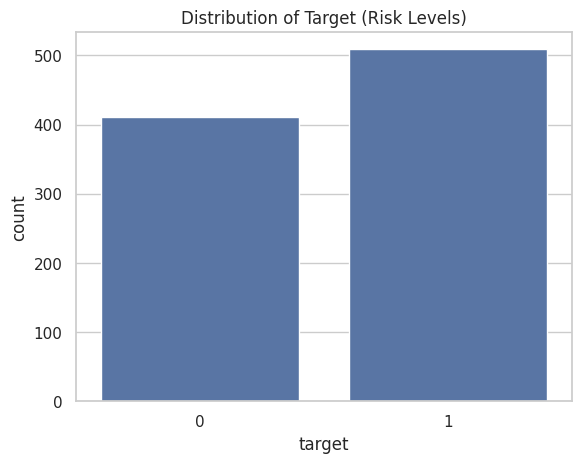

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df)
plt.title("Distribution of Target (Risk Levels)")
plt.show()

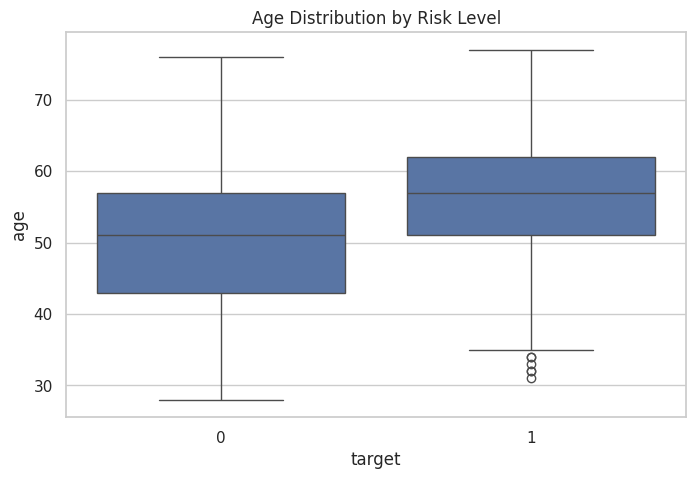

In [39]:
plt.figure(figsize=(8,5))
sns.boxplot(x='target', y='age', data=df)
plt.title("Age Distribution by Risk Level")
plt.show()

### Insights: Age vs Risk

The analysis shows that high-risk patients tend to be older on average.

However, there is significant overlap between low-risk and high-risk groups.

This indicates that age alone is not a reliable predictor of heart disease.

Relying solely on age could result in false reassurance, where high-risk patients are incorrectly classified as low-risk.

This highlights the need to consider multiple features when building a screening system.

### Chest Pain Type vs Risk

Chest pain type is a critical clinical feature used by doctors to assess heart disease risk.

We analyze how different chest pain categories relate to the presence of heart disease.

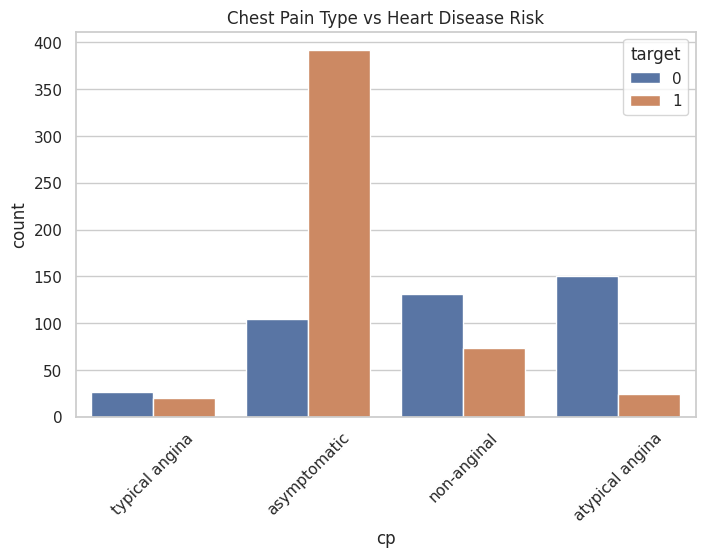

In [40]:
plt.figure(figsize=(8,5))
sns.countplot(x='cp', hue='target', data=df)
plt.title("Chest Pain Type vs Heart Disease Risk")
plt.xticks(rotation=45)
plt.show()

### Insights: Chest Pain Type vs Risk

Chest pain type shows a strong relationship with heart disease risk.

Patients categorized as **asymptomatic** have a significantly higher proportion of high-risk cases.

This is a critical insight, as it suggests that the absence of symptoms does not imply low risk.

On the other hand, categories such as **atypical angina** and **non-anginal pain** are more associated with low-risk patients.

### Key Observation

Relying solely on visible symptoms can be misleading.

Patients without clear symptoms may still be at high risk, which reinforces the importance of data-driven screening systems.

### Cholesterol vs Heart Disease Risk

Cholesterol is commonly considered a major risk factor for heart disease.

We analyze whether higher cholesterol levels are actually associated with increased risk in this dataset.

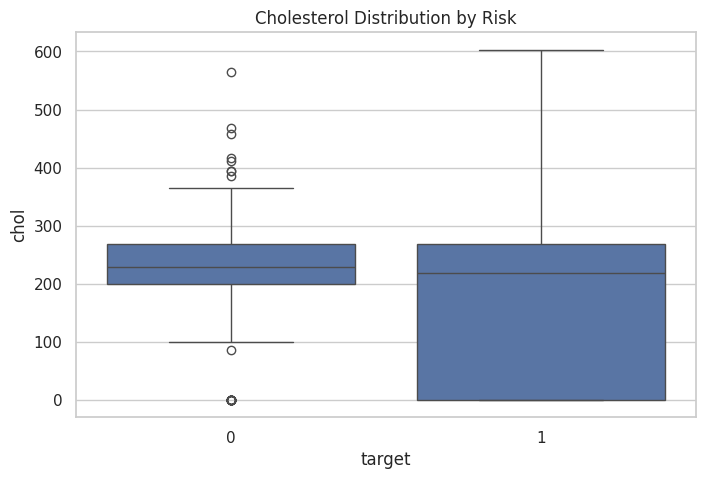

In [41]:
plt.figure(figsize=(8,5))
sns.boxplot(x='target', y='chol', data=df)
plt.title("Cholesterol Distribution by Risk")
plt.show()

### Note on Missing Values

The cholesterol feature contains missing values.

During exploratory analysis, these missing values are automatically ignored by plotting functions.

This may introduce bias if the missing values are not randomly distributed.

For example, if high-risk patients are more likely to have missing cholesterol values, the analysis may underestimate their risk.

This highlights the importance of handling missing data carefully before building predictive models.

### Insights: Cholesterol vs Risk

The analysis shows significant overlap in cholesterol levels between low-risk and high-risk patients.

This indicates that cholesterol alone is not a reliable predictor of heart disease.

Interestingly, some high-risk patients have relatively low cholesterol levels, while some low-risk patients have high values.

### Data Quality Concern

The presence of near-zero cholesterol values suggests potential data quality issues or missing value encoding.

If not handled properly, this can lead to misleading conclusions and affect model performance.

### Key Takeaway

Relying on cholesterol alone can result in incorrect risk assessment and possible false reassurance.

### Exercise-Induced Angina vs Risk

Exercise-induced angina indicates whether a patient experiences chest pain during physical activity.

This is an important clinical indicator that may be strongly associated with heart disease.

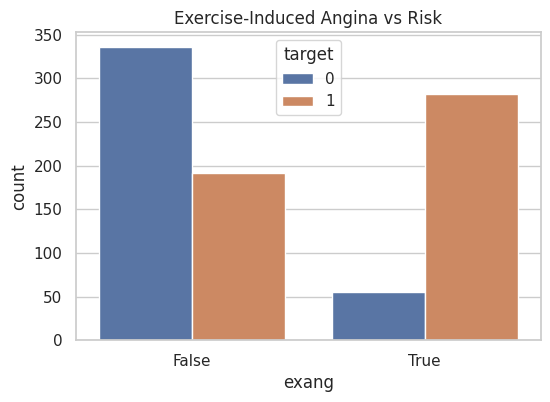

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x='exang', hue='target', data=df)
plt.title("Exercise-Induced Angina vs Risk")
plt.show()

### Insights: Exercise-Induced Angina vs Risk

Exercise-induced angina shows a strong relationship with heart disease risk.

Patients who experience angina during exercise (exang = True) are predominantly classified as high-risk.

This suggests that this feature is a strong indicator of heart disease.

However, some high-risk patients do not show exercise-induced angina, indicating that this feature alone is not sufficient for reliable prediction.

### Key Takeaway

While exercise-induced angina is a strong predictor, relying on it alone may still lead to missed high-risk cases.

A combination of multiple features is necessary for accurate screening.

### Dataset Source Analysis

The dataset contains data collected from multiple sources.

We analyze whether the distribution of heart disease risk varies across different datasets.

This is important because differences in data collection can introduce bias and affect model performance.

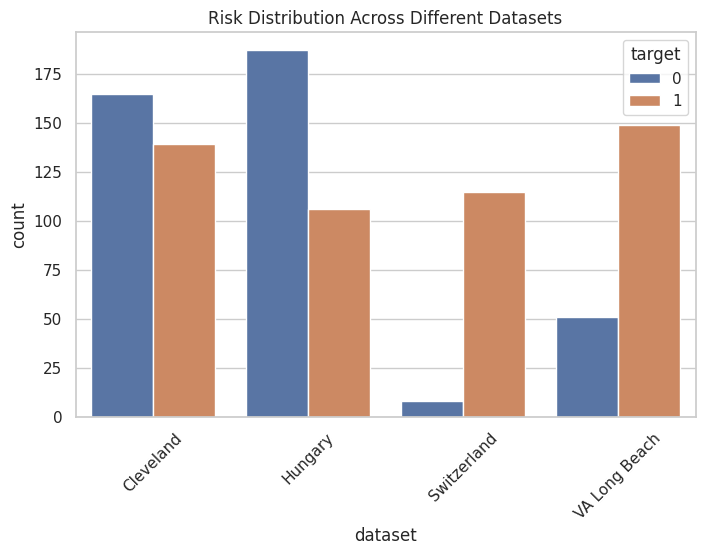

In [43]:
plt.figure(figsize=(8,5))
sns.countplot(x='dataset', hue='target', data=df)
plt.title("Risk Distribution Across Different Datasets")
plt.xticks(rotation=45)
plt.show()

### Insights: Dataset Source Bias

The dataset contains data collected from multiple sources, including Cleveland, Hungary, Switzerland, and VA Long Beach.

The distribution of heart disease risk varies significantly across these datasets.

For example:
- Some datasets have a higher proportion of high-risk patients
- Others are dominated by low-risk cases

### Key Risk

This variation suggests the presence of **data bias or domain shift**.

A model trained on one dataset may not perform well when applied to another population.

### Implication

This can lead to incorrect predictions and increased risk of false reassurance when deployed in real-world settings.

Care must be taken to ensure models generalize across different populations.

## Handling Missing Values

Several features contain a high proportion of missing values.

### Features with High Missingness

- `ca` (~66% missing)
- `thal` (~52% missing)
- `slope` (~33% missing)

### Decision

Features with very high missing values (`ca`, `thal`) are removed, as imputing such a large portion of data could introduce bias and lead to unreliable predictions.

The `slope` feature also contains a significant number of missing values and is removed to simplify the model and ensure data quality.

### Key Consideration

In healthcare applications, data quality is critical. Poor handling of missing values can lead to incorrect predictions and increase the risk of false reassurance.

In [44]:
df = df.drop(columns=['ca', 'thal', 'slope'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  num       920 non-null    int64  
 13  target    920 non-null    int64  
dtypes: float64(4), int64(4), object(6)
memory usage: 100.8+ KB


In [45]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


## Handling Remaining Missing Values

After removing highly incomplete features, several columns still contain missing values.

### Strategy

- Numerical features (`trestbps`, `chol`, `thalch`, `oldpeak`) are filled using the **median**, which is robust to outliers.
- Categorical features (`fbs`, `restecg`, `exang`) are filled using the **mode**, preserving the most common category.

### Reasoning

Dropping rows would result in significant data loss and potential bias.

Imputation allows us to retain data while maintaining reasonable statistical assumptions.

In [46]:
# Fill numerical columns with median
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_44802/1106097954.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [47]:
# Fill categorical columns with mode
cat_cols = ['fbs', 'restecg', 'exang']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_44802/883299227.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_44802/883299227.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].fillna(df[col].mode()[0], inplace=True)


In [48]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


## Encoding Categorical Variables

Machine learning models require numerical input, so categorical variables must be encoded.

### Strategy

- Binary categorical features (`sex`, `fbs`, `exang`) are converted into 0/1 format.
- Multi-category features (`cp`, `restecg`, `dataset`) are encoded using one-hot encoding.

### Reasoning

This approach preserves the structure of categorical data while allowing models to interpret it correctly.

In [49]:
df['fbs'].unique()

array([ True, False])

In [50]:
df['exang'].unique()

array([False,  True])

In [51]:
df['sex'].unique()

array(['Male', 'Female'], dtype=object)

In [52]:
# Fix binary columns
df['fbs'] = df['fbs'].astype(int)
df['exang'] = df['exang'].astype(int)

# Fix sex
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})

In [53]:
df = pd.get_dummies(df, columns=['cp', 'restecg', 'dataset'], drop_first=True)

In [54]:
df.head()

,id,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,num,target,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach
0,1,63,1,145.0,233.0,1,150.0,0,2.3,0,0,False,False,True,False,False,False,False,False
1,2,67,1,160.0,286.0,0,108.0,1,1.5,2,1,False,False,False,False,False,False,False,False
2,3,67,1,120.0,229.0,0,129.0,1,2.6,1,1,False,False,False,False,False,False,False,False
3,4,37,1,130.0,250.0,0,187.0,0,3.5,0,0,False,True,False,True,False,False,False,False
4,5,41,0,130.0,204.0,0,172.0,0,1.4,0,0,True,False,False,False,False,False,False,False


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        920 non-null    int64  
 1   age                       920 non-null    int64  
 2   sex                       920 non-null    int64  
 3   trestbps                  920 non-null    float64
 4   chol                      920 non-null    float64
 5   fbs                       920 non-null    int64  
 6   thalch                    920 non-null    float64
 7   exang                     920 non-null    int64  
 8   oldpeak                   920 non-null    float64
 9   num                       920 non-null    int64  
 10  target                    920 non-null    int64  
 11  cp_atypical angina        920 non-null    bool   
 12  cp_non-anginal            920 non-null    bool   
 13  cp_typical angina         920 non-null    bool   
 14  restecg_no

In [56]:
# Convert all boolean columns to int
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [57]:
df.head()

,id,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,num,target,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach
0,1,63,1,145.0,233.0,1,150.0,0,2.3,0,0,0,0,1,0,0,0,0,0
1,2,67,1,160.0,286.0,0,108.0,1,1.5,2,1,0,0,0,0,0,0,0,0
2,3,67,1,120.0,229.0,0,129.0,1,2.6,1,1,0,0,0,0,0,0,0,0
3,4,37,1,130.0,250.0,0,187.0,0,3.5,0,0,0,1,0,1,0,0,0,0
4,5,41,0,130.0,204.0,0,172.0,0,1.4,0,0,1,0,0,0,0,0,0,0


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        920 non-null    int64  
 1   age                       920 non-null    int64  
 2   sex                       920 non-null    int64  
 3   trestbps                  920 non-null    float64
 4   chol                      920 non-null    float64
 5   fbs                       920 non-null    int64  
 6   thalch                    920 non-null    float64
 7   exang                     920 non-null    int64  
 8   oldpeak                   920 non-null    float64
 9   num                       920 non-null    int64  
 10  target                    920 non-null    int64  
 11  cp_atypical angina        920 non-null    int64  
 12  cp_non-anginal            920 non-null    int64  
 13  cp_typical angina         920 non-null    int64  
 14  restecg_no

## Train-Test Split

Before building a model, we split the dataset into training and testing sets.

- Training set → used to train the model  
- Test set → used to evaluate performance on unseen data  

This helps ensure that the model generalizes well and avoids overfitting.

In [59]:
from sklearn.model_selection import train_test_split

# Features (X) and target (y)
X = df.drop(columns=['num', 'target', 'id'])
y = df['target']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (736, 16)
X_test: (184, 16)
y_train: (736,)
y_test: (184,)


## Logistic Regression Model

We start with Logistic Regression as a baseline model.

This model is simple, interpretable, and commonly used in healthcare applications.

It provides a good starting point before exploring more complex models.

### Why Logistic Regression?

- Easy to interpret
- Works well for binary classification
- Suitable for medical decision-making scenarios

## Feature Scaling

Logistic Regression is sensitive to the scale of input features.

Since our dataset contains features with different ranges, we apply standardization.

This ensures that all features contribute equally to the model training process.

In [60]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

In [61]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

## Model Evaluation

To evaluate the model, we focus on metrics that reflect real-world impact.

In healthcare screening, false negatives are the most critical error.

Therefore, we analyze:

- Confusion Matrix
- Recall (Sensitivity)
- Precision
- F1 Score

In [62]:
y_pred = model.predict(X_test_scaled)

In [63]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[65 17]
 [14 88]]


### Confusion Matrix Analysis

The model performance is evaluated using a confusion matrix.

- True Negatives: 65
- False Positives: 17
- False Negatives: 14
- True Positives: 88

### Critical Observation

The model incorrectly classified 14 high-risk patients as low-risk.

These false negatives are particularly dangerous in a healthcare setting, as they may lead to delayed diagnosis and treatment.

### Key Insight

Even though the model performs reasonably well, reducing false negatives is crucial to ensure patient safety.

In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.79      0.81        82
           1       0.84      0.86      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



### Model Performance Analysis

The model achieves an overall accuracy of 83%, indicating reasonable predictive performance.

However, in a healthcare screening context, recall for the high-risk class is the most important metric.

### Key Observations

- Recall (High Risk): 86%
- This means the model correctly identifies most high-risk patients.

### Critical Concern

Despite good performance, the model fails to detect some high-risk patients (false negatives).

These cases are particularly dangerous, as they may lead to delayed diagnosis and treatment.

### Conclusion

Improving recall and reducing false negatives should be prioritized over simply maximizing accuracy.

In [65]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [66]:
import numpy as np

# Lower threshold (try 0.4)
y_pred_new = (y_prob >= 0.4).astype(int)

In [67]:
from sklearn.metrics import confusion_matrix

cm_new = confusion_matrix(y_test, y_pred_new)
print(cm_new)

[[58 24]
 [ 9 93]]


## Threshold Optimization

The default classification threshold (0.5) was adjusted to improve recall.

### Results

- False Negatives reduced from 14 → 9
- True Positives increased from 88 → 93
- False Positives increased from 17 → 24

### Interpretation

Lowering the threshold allows the model to identify more high-risk patients.

Although this increases false positives, it reduces the number of missed high-risk cases.

### Key Insight

In healthcare screening, it is often preferable to accept more false positives rather than miss critical cases.

This adjustment helps reduce the risk of false reassurance.

## Conclusion

This project demonstrates how a data-driven approach can support early detection of heart disease.

### Key Findings

- Some features (e.g., exercise-induced angina) strongly correlate with risk
- Others (e.g., cholesterol) are less reliable on their own
- Data quality issues can significantly impact model performance

### Critical Insight

Even well-performing models can produce false negatives, which are dangerous in healthcare.

By adjusting the classification threshold, we were able to reduce missed high-risk cases.

### Final Takeaway

The goal of a healthcare screening system is not just accuracy, but minimizing harmful errors and supporting better decision-making.

## Random Forest Model

To improve performance and capture complex patterns, we use a Random Forest classifier.

Random Forest is an ensemble model that combines multiple decision trees to improve accuracy and robustness.

### Why Random Forest?

- Captures non-linear relationships
- Handles feature interactions better
- Less sensitive to scaling compared to Logistic Regression

In [68]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(random_state=42)

# Train (no scaling needed)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [69]:
y_pred_rf = rf_model.predict(X_test)

In [70]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[65 17]
 [13 89]]


## Model Comparison

We compared Logistic Regression and Random Forest models.

### Results

- Logistic Regression (default): FN = 14
- Logistic Regression (tuned): FN = 9
- Random Forest: FN = 13

### Key Insight

Random Forest, despite being more complex, did not outperform Logistic Regression in reducing false negatives.

Logistic Regression with threshold tuning achieved the best performance in identifying high-risk patients.

### Trade-off

Lowering the threshold increased false positives but significantly reduced dangerous false negatives.

### Conclusion

In healthcare screening, simpler models with proper tuning may outperform more complex models when evaluated based on real-world impact.

In [71]:
import pandas as pd

# Get feature importance
importances = rf_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance.head(10)

,feature,importance
3,chol,0.144640
5,thalch,0.142757
7,oldpeak,0.125345
0,age,0.121807
6,exang,0.095673
2,trestbps,0.082843
8,cp_atypical angina,0.069973
1,sex,0.049186
9,cp_non-anginal,0.034347
14,dataset_Switzerland,0.032860


## Feature Importance Analysis

Feature importance from the Random Forest model highlights the most influential variables.

### Top Features

- Cholesterol (`chol`)
- Maximum heart rate (`thalch`)
- ST depression (`oldpeak`)
- Age
- Exercise-induced angina (`exang`)

### Key Observation

Some features, such as `thalch`, `oldpeak`, and `exang`, align well with known medical risk factors.

However, cholesterol appears as the most important feature despite weak separation observed during EDA.

### Critical Insight

Feature importance reflects patterns learned by the model, but does not necessarily indicate a reliable or causal relationship.

This highlights the importance of combining statistical analysis with domain understanding.

### Takeaway

Model interpretation must be done carefully, especially in healthcare applications, to avoid misleading conclusions.